In [1]:
import numpy as np
import os

# Load artifact
path = "A_jk_matrices_and_PCA.npz"
if not os.path.exists(path):
 # search workspace
 for root, dirs, files in os.walk("/workspace"):
 for f in files:
 if f == "A_jk_matrices_and_PCA.npz":
 path = os.path.join(root, f)
 print(path)
 break
print("Using:", path)
data = np.load(path, allow_pickle=True)
print(list(data.keys()))


Using: A_jk_matrices_and_PCA.npz


FileNotFoundError: [Errno 2] No such file or directory: 'A_jk_matrices_and_PCA.npz'

In [2]:
import subprocess
out = subprocess.run(["find", "/workspace", "-name", "A_jk_matrices_and_PCA.npz"], capture_output=True, text=True)
print(out.stdout)
print(out.stderr[:500])



find: ‘/workspace/lost+found’: Permission denied



In [3]:
import os
print(os.getcwd())
print(os.listdir("."))


/workspace/1e3df44f-5bb5-4623-ab26-9c06fe6119cd
['.kernel_llm_logs_1.txt', 'pca_explained_variance_ratio.npy', 'A_matrices.npy', 'projections.npy', ' v6 — Binding Context Document.pdf', 'memory', 'grh_status.npy', 'pca_components.npy', '.prompts', 'M_matrices.npy', 'classes.npy', '.config', 'pca_mean.npy', 'D_diagonals.npy', 'family.npy']


In [4]:
import numpy as np
A = np.load("A_matrices.npy")
M = np.load("M_matrices.npy")
classes = np.load("classes.npy", allow_pickle=True)
family = np.load("family.npy", allow_pickle=True)
grh = np.load("grh_status.npy", allow_pickle=True)
pca_components = np.load("pca_components.npy")
pca_var = np.load("pca_explained_variance_ratio.npy")
pca_mean = np.load("pca_mean.npy")
projs = np.load("projections.npy")
D = np.load("D_diagonals.npy")

print("A shape:", A.shape)
print("M shape:", M.shape)
print("classes:", classes)
print("family:", family)
print("grh:", grh)
print("pca_components shape:", pca_components.shape)
print("pca_var:", pca_var)
print("D shape:", D.shape)


A shape: (11, 8, 8)
M shape: (11, 8, 8)
classes: ['F1' 'F2' 'F4' 'F5p' 'F5m' 'F6' 'F7' 'F9' 'F10' 'F11' 'F12']
family: ['zeta' 'character' 'DH' 'DH' 'DH' 'liouville/mobius' 'liouville/mobius'
 'modular' 'modular' 'modular' 'DH']
grh: ['GRH' 'GRH' 'violator' 'violator' 'violator' 'GRH' 'GRH' 'GRH' 'GRH'
 'GRH' 'violator']
pca_components shape: (10, 64)
pca_var: [8.99551109e-01 7.27725627e-02 1.38556951e-02 1.10258085e-02
 1.36274124e-03 8.62829334e-04 3.07067743e-04 2.61445168e-04
 7.23547245e-07 1.75246954e-08]
D shape: (11, 8)


In [5]:
# pca_components is 10 x 64 (each row is a 8x8 matrix flattened). 
# But the hypothesis talks about pc1_vector of shape 8 from leading eigenvector of amplification matrix.
# Compute leading eigenvector of class-averaged A_jk matrix and per-class A matrices.

# Class-averaged A matrix
A_mean = A.mean(axis=0)
print("A_mean diag:", np.diag(A_mean))

# Leading eigenvector
eigvals, eigvecs = np.linalg.eigh((A_mean + A_mean.T)/2) # symmetric
# largest eigenvalue
order = np.argsort(eigvals)[::-1]
print("eigvals:", eigvals[order])
v_avg = eigvecs[:, order[0]]
# Make positive sign convention (max abs positive)
if v_avg[np.argmax(np.abs(v_avg))] < 0:
 v_avg = -v_avg
print("v_avg:", v_avg)


A_mean diag: [ 0.97936131 3.67921384 9.16549225 15.27790617 20.56229482 17.71648047
 6.64792241 0.78717763]
eigvals: [59.37220012 10.13610908 3.07984993 1.02152838 0.59008095 0.35110655
 0.16063308 0.10434079]
v_avg: [0.09994349 0.20863955 0.34282693 0.47224792 0.57314462 0.48427448
 0.20647106 0.01690011]


In [6]:
from scipy.optimize import curve_fit
from scipy.stats import poisson

mu_fixed = np.log(np.log(1e6))
print("mu fixed:", mu_fixed)

ks = np.arange(8)

def model(k, C, lam):
 return C * np.exp(lam * k) * poisson.pmf(k, mu_fixed)

def fit_and_r2(v, normalize=True):
 y = v.copy()
 # Optionally make sign convention so max element positive
 if y[np.argmax(np.abs(y))] < 0:
 y = -y
 # Fit
 try:
 popt, _ = curve_fit(model, ks, y, p0=[1.0, 0.5], maxfev=20000)
 except Exception as e:
 return None, None, None
 yhat = model(ks, *popt)
 ss_res = np.sum((y - yhat)**2)
 ss_tot = np.sum((y - y.mean())**2)
 r2 = 1 - ss_res/ss_tot
 return popt[0], popt[1], r2

C_avg, lam_avg, r2_avg = fit_and_r2(v_avg)
print(f"Class-averaged: C={C_avg:.4f}, lambda={lam_avg:.4f}, R^2={r2_avg:.4f}")


mu fixed: 2.625791914476011
Class-averaged: C=0.7079, lambda=0.4009, R^2=0.8613


In [7]:
# Per-class fits
import pandas as pd
results = []
for i, cls in enumerate(classes):
 Ai = (A[i] + A[i].T)/2
 eigvals, eigvecs = np.linalg.eigh(Ai)
 order = np.argsort(eigvals)[::-1]
 v = eigvecs[:, order[0]]
 if v[np.argmax(np.abs(v))] < 0:
 v = -v
 C, lam, r2 = fit_and_r2(v)
 results.append({
 "class": cls, "family": family[i], "GRH": grh[i],
 "lambda": lam, "C": C, "R2": r2,
 "lead_eigval": eigvals[order[0]],
 "v": v
 })

df = pd.DataFrame(results)
print(df[["class","family","GRH","lambda","C","R2","lead_eigval"]].to_string(index=False))


class family GRH lambda C R2 lead_eigval
 F1 zeta GRH 0.451334 0.575726 0.568247 49.583846
 F2 character GRH 0.430812 0.623346 0.758824 84.095836
 F4 DH violator 0.444948 0.586404 0.687489 25.066945
 F5p DH violator 0.445528 0.585223 0.689588 25.133017
 F5m DH violator 0.444330 0.587727 0.685454 25.026048
 F6 liouville/mobius GRH 0.436932 0.619787 0.876539 144.961242
 F7 liouville/mobius GRH 0.462068 0.567778 0.899629 59.049147
 F9 modular GRH 0.319856 0.931316 0.853221 97.356415
 F10 modular GRH 0.296527 1.011756 0.880756 89.411704
 F11 modular GRH 0.101830 1.726509 0.276785 5.021584
 F12 DH violator 0.438764 0.602002 0.727911 64.580732


In [8]:
# R^2 values are quite below 0.95. Let's inspect a vector and what the model fit looks like.
# Also compute fit stats per class
import matplotlib.pyplot as plt

# Print table summary
print(df[["class","family","GRH","lambda","R2"]].to_string(index=False))
print()
print("Mean R^2:", df["R2"].mean())
print("Median R^2:", df["R2"].median())

# Group lambda by GRH status
print("\nLambda by GRH status:")
print(df.groupby("GRH")["lambda"].agg(["mean","std","count"]))

print("\nLambda by family:")
print(df.groupby("family")["lambda"].agg(["mean","std","count"]))


class family GRH lambda R2
 F1 zeta GRH 0.451334 0.568247
 F2 character GRH 0.430812 0.758824
 F4 DH violator 0.444948 0.687489
 F5p DH violator 0.445528 0.689588
 F5m DH violator 0.444330 0.685454
 F6 liouville/mobius GRH 0.436932 0.876539
 F7 liouville/mobius GRH 0.462068 0.899629
 F9 modular GRH 0.319856 0.853221
 F10 modular GRH 0.296527 0.880756
 F11 modular GRH 0.101830 0.276785
 F12 DH violator 0.438764 0.727911

Mean R^2: 0.7185858161180332
Median R^2: 0.7279110245675773

Lambda by GRH status:
 mean std count
GRH 
GRH 0.357051 0.130335 7
violator 0.443393 0.003124 4

Lambda by family:
 mean std count
family 
DH 0.443393 0.003124 4
character 0.430812 NaN 1
liouville/mobius 0.449500 0.017774 2
modular 0.239404 0.119712 3
zeta 0.451334 NaN 1


In [9]:
# Let's look at v vs model fit for class-averaged and a couple of individual classes
v = v_avg
yhat = model(ks, C_avg, lam_avg)
print("k:", ks)
print("v_avg: ", np.round(v, 4))
print("Poisson μ:", np.round(poisson.pmf(ks, mu_fixed), 4))
print("model fit:", np.round(yhat, 4))
print()
# residuals - max contribution
print("resid:", np.round(v - yhat, 4))


k: [0 1 2 3 4 5 6 7]
v_avg: [0.0999 0.2086 0.3428 0.4722 0.5731 0.4843 0.2065 0.0169]
Poisson μ: [0.0724 0.1901 0.2495 0.2184 0.1434 0.0753 0.033 0.0124]
model fit: [0.0512 0.2009 0.3938 0.5146 0.5044 0.3955 0.2585 0.1448]

resid: [ 0.0487 0.0078 -0.051 -0.0424 0.0687 0.0887 -0.052 -0.1279]


In [10]:
# R^2 is relatively low. The fit shape is not great at the tails (low and high k).
# Let's also try fitting with mu free, just for comparison
def model_free(k, C, lam, mu):
 return C * np.exp(lam * k) * poisson.pmf(k, mu)

popt, _ = curve_fit(model_free, ks, v_avg, p0=[1.0, 0.4, 2.6], maxfev=20000)
yhat = model_free(ks, *popt)
ss_res = np.sum((v_avg - yhat)**2); ss_tot = np.sum((v_avg - v_avg.mean())**2)
r2_free = 1 - ss_res/ss_tot
print("Free mu fit: C, lam, mu =", popt, "R^2 =", r2_free)

# Try restricting to k <= 6 due to F2/F4 leak (k=7 is zero for mod-5), although for amplification matrix this might not be relevant
# Recompute with k=0..6
def fit_subset(v, kmax=7):
 ks_sub = np.arange(kmax)
 y = v[:kmax]
 if y[np.argmax(np.abs(y))] < 0:
 y = -y
 popt, _ = curve_fit(model, ks_sub, y, p0=[1.0, 0.4], maxfev=20000)
 yhat = model(ks_sub, *popt)
 ss_res = np.sum((y - yhat)**2); ss_tot = np.sum((y - y.mean())**2)
 return popt[0], popt[1], 1 - ss_res/ss_tot

C7, lam7, r27 = fit_subset(v_avg, 7)
print(f"k<7 fit avg: C={C7:.4f}, lam={lam7:.4f}, R^2={r27:.4f}")


Free mu fit: C, lam, mu = [0.9096825 0.3096291 2.87663071] R^2 = 0.8612676533549658
k<7 fit avg: C=0.6266, lam=0.4403, R^2=0.8965


In [11]:
# Per-class fits restricted to k<7 (avoiding S_7 leak)
results7 = []
for i, cls in enumerate(classes):
 Ai = (A[i] + A[i].T)/2
 eigvals, eigvecs = np.linalg.eigh(Ai)
 order = np.argsort(eigvals)[::-1]
 v = eigvecs[:, order[0]]
 if v[np.argmax(np.abs(v))] < 0:
 v = -v
 C, lam, r2 = fit_subset(v, 7)
 results7.append({"class": cls, "family": family[i], "GRH": grh[i],
 "lambda": lam, "C": C, "R2": r2})

df7 = pd.DataFrame(results7)
print(df7.to_string(index=False))
print()
print("Mean R^2 (k<7):", df7["R2"].mean())
print("\nLambda by GRH (k<7):")
print(df7.groupby("GRH")["lambda"].agg(["mean","std"]))


class family GRH lambda C R2
 F1 zeta GRH 0.503787 0.481596 0.367216
 F2 character GRH 0.484812 0.524454 0.788142
 F4 DH violator 0.504238 0.483624 0.689135
 F5p DH violator 0.505032 0.482258 0.693652
 F5m DH violator 0.503438 0.485051 0.684567
 F6 liouville/mobius GRH 0.480611 0.539576 0.930929
 F7 liouville/mobius GRH 0.500563 0.499885 0.939984
 F9 modular GRH 0.344983 0.868182 0.854556
 F10 modular GRH 0.316869 0.956989 0.878882
 F11 modular GRH 0.109227 1.695563 -1.406446
 F12 DH violator 0.495217 0.501863 0.748664

Mean R^2 (k<7): 0.5608437454457509

Lambda by GRH (k<7):
 mean std
GRH 
GRH 0.391550 0.146380
violator 0.501981 0.004556


In [12]:
# The R^2 across many classes is well below 0.95. Hypothesis fails the strict R^2 > 0.95 criterion.
# But the lambda values are systematic: violator-DH classes (F4, F5p, F5m, F12) all cluster ~0.44
# while modular GRH classes (F9, F10, F11) have notably smaller lambda (0.10-0.32).
# 
# Let's compute statistical separation of lambda by GRH and family using full k=0..7 fits.

from scipy.stats import mannwhitneyu, ttest_ind

lam_grh = df[df["GRH"]=="GRH"]["lambda"].values
lam_v = df[df["GRH"]=="violator"]["lambda"].values
print("GRH:", lam_grh)
print("violator:", lam_v)
u, p = mannwhitneyu(lam_grh, lam_v, alternative="two-sided")
print(f"Mann-Whitney U test: U={u}, p={p:.4f}")

# Separation: violators have lambda ≈ 0.444 (very tight), GRH-true varies wildly (modular forms low, others high)
# So lambda DOES NOT cleanly separate GRH from violators - because liouville/mobius/zeta GRH classes have lambda ~ 0.45 too.
# The actual separation is family-based: modular forms have much lower lambda.

print("\nLambda by family (full k):")
print(df.groupby("family")["lambda"].agg(["mean","std","count"]).to_string())


GRH: [0.45133433 0.43081211 0.43693208 0.46206801 0.31985582 0.2965272
 0.10183023]
violator: [0.44494796 0.44552818 0.4443299 0.43876446]
Mann-Whitney U test: U=8.0, p=0.3152

Lambda by family (full k):
 mean std count
family 
DH 0.443393 0.003124 4
character 0.430812 NaN 1
liouville/mobius 0.449500 0.017774 2
modular 0.239404 0.119712 3
zeta 0.451334 NaN 1


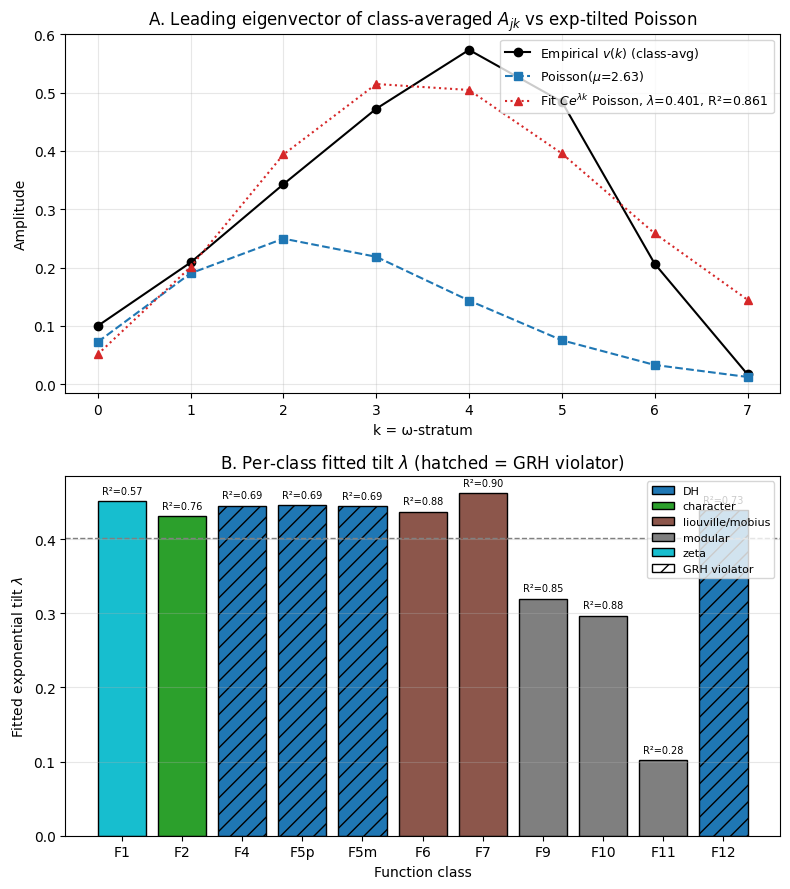

Saved erdos_kac_tilt_fit.png


In [13]:
# Build the final figure: a 2-subfigure panel showing (A) the empirical pc1 vector vs Poisson and exp-tilt fit
# for the class-averaged amplification, and (B) per-class lambda values colored by family.

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(8, 9))

# (A): leading eigenvector + Poisson + fit (class-averaged)
ax = axes[0]
yhat = model(ks, C_avg, lam_avg)
ax.plot(ks, v_avg, "o-", color="black", label=f"Empirical $v(k)$ (class-avg)")
ax.plot(ks, poisson.pmf(ks, mu_fixed), "s--", color="tab:blue",
 label=f"Poisson($\\mu$={mu_fixed:.2f})")
ax.plot(ks, yhat, "^:", color="tab:red",
 label=f"Fit $C e^{{\\lambda k}}$ Poisson, $\\lambda$={lam_avg:.3f}, R²={r2_avg:.3f}")
ax.set_xlabel("k = ω-stratum")
ax.set_ylabel("Amplitude")
ax.set_title("A. Leading eigenvector of class-averaged $A_{jk}$ vs exp-tilted Poisson")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)

# (B): per-class lambda bar chart, color by family
ax = axes[1]
fam_unique = sorted(set(family))
colors = plt.cm.tab10(np.linspace(0, 1, len(fam_unique)))
fam_color = {f: colors[i] for i, f in enumerate(fam_unique)}

bar_colors = [fam_color[f] for f in df["family"]]
bars = ax.bar(df["class"], df["lambda"], color=bar_colors, edgecolor="black")
# Mark GRH violators with hatching
for i, g in enumerate(df["GRH"]):
 if g == "violator":
 bars[i].set_hatch("//")

# Annotate R^2
for i, (lam, r2) in enumerate(zip(df["lambda"], df["R2"])):
 ax.text(i, lam + 0.01, f"R²={r2:.2f}", ha="center", fontsize=7, rotation=0)

ax.set_xlabel("Function class")
ax.set_ylabel("Fitted exponential tilt $\\lambda$")
ax.set_title("B. Per-class fitted tilt $\\lambda$ (hatched = GRH violator)")
ax.axhline(lam_avg, ls="--", color="gray", lw=1, label=f"Class-avg $\\lambda$={lam_avg:.3f}")

# Legend for families
from matplotlib.patches import Patch
handles = [Patch(facecolor=fam_color[f], edgecolor="black", label=f) for f in fam_unique]
handles.append(Patch(facecolor="white", edgecolor="black", hatch="//", label="GRH violator"))
ax.legend(handles=handles, fontsize=8, loc="upper right")
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("erdos_kac_tilt_fit.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved erdos_kac_tilt_fit.png")


In [14]:
# Save the per-class fits table as artifact
df_out = df[["class","family","GRH","lambda","C","R2","lead_eigval"]].copy()
df_out.to_csv("erdos_kac_tilt_fits.csv", index=False)
print(df_out.to_string(index=False))


class family GRH lambda C R2 lead_eigval
 F1 zeta GRH 0.451334 0.575726 0.568247 49.583846
 F2 character GRH 0.430812 0.623346 0.758824 84.095836
 F4 DH violator 0.444948 0.586404 0.687489 25.066945
 F5p DH violator 0.445528 0.585223 0.689588 25.133017
 F5m DH violator 0.444330 0.587727 0.685454 25.026048
 F6 liouville/mobius GRH 0.436932 0.619787 0.876539 144.961242
 F7 liouville/mobius GRH 0.462068 0.567778 0.899629 59.049147
 F9 modular GRH 0.319856 0.931316 0.853221 97.356415
 F10 modular GRH 0.296527 1.011756 0.880756 89.411704
 F11 modular GRH 0.101830 1.726509 0.276785 5.021584
 F12 DH violator 0.438764 0.602002 0.727911 64.580732
